In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from scipy.stats import norm
from scipy import stats
from pathlib import Path
# Disable Jupyter output truncation completely
from IPython.display import display
import sys
# Import necessary modules
from scipy import stats as sp_stats
from scipy.stats import gaussian_kde
# Calculate Pearson correlation with p-values
from scipy.stats import pearsonr

# Display with better formatting - all columns visible
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [95]:
# Gets the parent directory of the current working directory
project_root = Path.cwd().parent.parent
fullpath = "{}/data/VST152/pva_donors.csv".format(project_root)
donor_data = pd.read_csv(fullpath)

# Simple Linear Regression Analysis - Donation Amount

## Overview

This notebook performs a comprehensive simple linear regression analysis to understand the relationship between **Donation_Amt** (dependent variable) and **GiftAvgCard36** (independent variable).

### Analysis Components

1. **Data Summary Tables**
   - Observations read, used, and missing
   - Data quality assessment

2. **Analysis of Variance (ANOVA)**
   - Model fit assessment
   - Statistical significance of the regression

3. **Model Fit Statistics**
   - R-Square and Adjusted R-Square
   - Root Mean Square Error (RMSE)
   - Coefficient of Variation

4. **Parameter Estimates**
   - Intercept and slope coefficients
   - Standard errors and t-values
   - 95% confidence intervals
   - Statistical significance testing

5. **Diagnostic Plots**
   - Residuals vs Predicted values
   - Q-Q plot for normality
   - Scale-Location plot
   - Residuals vs Leverage

6. **Prediction Plots**
   - Observed vs Predicted values
   - Scatter plot with regression line and confidence bands

### Research Question

**Does the average credit card gift amount (GiftAvgCard36) significantly predict the donation amount?**

### Variables

- **Dependent Variable (Y)**: Donation_Amt (Donation Amount in dollars)
- **Independent Variable (X)**: GiftAvgCard36 (Average Credit Card Gift in 36 months)

In [96]:
# Column descriptions
col_descriptions = {
    'GiftAvgCard36': 'Average Credit Card Gift (36 Months)',
    'Donation_Amt': 'Donation Amount'
}

# Prepare data for regression
# Remove rows with missing values in either variable
regression_data = donor_data[['GiftAvgCard36', 'Donation_Amt']].dropna()

# Calculate data summary statistics
total_obs = len(donor_data)
used_obs = len(regression_data)
missing_obs = total_obs - used_obs

print(f"Total observations in dataset: {total_obs:,}")
print(f"Observations used in analysis: {used_obs:,}")
print(f"Missing values: {missing_obs:,}")
print(f"Percentage used: {(used_obs/total_obs)*100:.2f}%")

Total observations in dataset: 9,686
Observations used in analysis: 4,111
Missing values: 5,575
Percentage used: 42.44%


## TABLE 1: DATA SUMMARY

Overview of data availability and completeness for the regression analysis.

In [97]:
# TABLE 1: Data Summary
data_summary = pd.DataFrame({
    'Category': ['Number of Observations Read', 'Number of Observations Used', 'Number of Missing Values'],
    'Count': [total_obs, used_obs, missing_obs]
})

data_summary_display = data_summary.copy()
data_summary_display.index.name = None
display(data_summary_display)

,Category,Count
0,Number of Observations Read,9686
1,Number of Observations Used,4111
2,Number of Missing Values,5575


In [98]:
# Fit the linear regression model using statsmodels
X = regression_data['GiftAvgCard36']
y = regression_data['Donation_Amt']

# Add constant for intercept
X_with_const = sm.add_constant(X)

# Fit OLS regression
model = sm.OLS(y, X_with_const)
results = model.fit()

# Get predictions and residuals
y_pred = results.fittedvalues
residuals = results.resid

# Calculate ANOVA components
n = len(y)
k = 1  # number of predictors (excluding intercept)
dof_model = k
dof_error = n - k - 1
dof_total = n - 1

# Sum of Squares
ss_total = np.sum((y - y.mean())**2)
ss_model = np.sum((y_pred - y.mean())**2)
ss_error = np.sum(residuals**2)

# Mean Squares
ms_model = ss_model / dof_model
ms_error = ss_error / dof_error

# F-statistic and p-value
f_stat = ms_model / ms_error
f_pvalue = 1 - sp_stats.f.cdf(f_stat, dof_model, dof_error)

print(f"Model fitted successfully!")
print(f"R-squared: {results.rsquared:.6f}")
print(f"Adjusted R-squared: {results.rsquared_adj:.6f}")

Model fitted successfully!
R-squared: 0.416473
Adjusted R-squared: 0.416331


## TABLE 2: ANALYSIS OF VARIANCE (ANOVA)

Tests whether the regression model is statistically significant overall.

### Why ANOVA?

The ANOVA table answers: **"Does the model explain a significant portion of the variation in Donation_Amt?"**

- **Model**: Variation explained by GiftAvgCard36
- **Error**: Unexplained variation (residuals)
- **Corrected Total**: Total variation in Donation_Amt

### Interpretation

- **F Value**: Ratio of explained to unexplained variance
  - Large F → Model explains significant variation
  - Small F → Model explains little variation
  
- **Pr > F**: P-value for the F-test
  - p < 0.05 → Model is statistically significant
  - p ≥ 0.05 → Model is not statistically significant

In [99]:
# TABLE 2: Analysis of Variance
anova_table = pd.DataFrame({
    'Source': ['Model', 'Error', 'Corrected Total'],
    'DF': [dof_model, dof_error, dof_total],
    'Sum of Squares': [ss_model, ss_error, ss_total],
    'Mean Square': [ms_model, ms_error, np.nan],
    'F Value': [f_stat, np.nan, np.nan],
    'Pr > F': [f_pvalue, np.nan, np.nan]
})

# Format for display
anova_display = anova_table.copy()
anova_display['Sum of Squares'] = anova_display['Sum of Squares'].apply(lambda x: f'{x:.2f}' if not np.isnan(x) else '')
anova_display['Mean Square'] = anova_display['Mean Square'].apply(lambda x: f'{x:.2f}' if not np.isnan(x) else '')
anova_display['F Value'] = anova_display['F Value'].apply(lambda x: f'{x:.4f}' if not np.isnan(x) else '')
anova_display['Pr > F'] = anova_display['Pr > F'].apply(lambda x: f'{x:.6f}' if not np.isnan(x) else '')

anova_display.index.name = None
display(anova_display)

,Source,DF,Sum of Squares,Mean Square,F Value,Pr > F
0,Model,1,1149895.27,1149895.27,2932.6643,0.000000
1,Error,4109,1611135.55,392.10,,
2,Corrected Total,4110,2761030.82,,,


## TABLE 3: MODEL FIT STATISTICS

Summary of model performance and prediction accuracy.

### Key Metrics

- **Root MSE**: Square root of Mean Squared Error
  - Measures average prediction error in original units (dollars)
  - Smaller is better
  
- **Dependent Mean**: Average value of Donation_Amt
  - Baseline for comparison
  
- **Coeff Var**: Coefficient of Variation = (Root MSE / Mean) × 100
  - Percentage of mean that represents prediction error
  - Smaller is better
  
- **R-Square**: Proportion of variance explained by the model
  - Range: 0 to 1
  - 0.5 = Model explains 50% of variation
  - Larger is better
  
- **Adj R-Sq**: Adjusted R-Square
  - Penalizes for adding more predictors
  - Better for comparing models with different numbers of variables

In [100]:
# TABLE 3: Model Fit Statistics
root_mse = np.sqrt(ms_error)
dependent_mean = y.mean()
coeff_var = (root_mse / dependent_mean) * 100

fit_stats = pd.DataFrame({
    'Statistic': ['Root MSE', 'Dependent Mean', 'Coeff Var', 'R-Square', 'Adj R-Sq'],
    'Value': [
        f'${root_mse:.2f}',
        f'${dependent_mean:.2f}',
        f'{coeff_var:.2f}%',
        f'{results.rsquared:.6f}',
        f'{results.rsquared_adj:.6f}'
    ]
})

fit_stats_display = fit_stats.copy()
fit_stats_display.index.name = None
display(fit_stats_display)

,Statistic,Value
0,Root MSE,$19.80
1,Dependent Mean,$99.48
2,Coeff Var,19.91%
3,R-Square,0.416473
4,Adj R-Sq,0.416331


## TABLE 4: PARAMETER ESTIMATES

Regression coefficients with 95% confidence intervals and statistical significance tests.

### Why Parameter Estimates?

The regression equation is: **Donation_Amt = Intercept + Slope × GiftAvgCard36**

- **Intercept**: Expected Donation_Amt when GiftAvgCard36 = 0
- **Slope (GiftAvgCard36)**: Change in Donation_Amt for each $1 increase in GiftAvgCard36

### Interpretation of Each Column

- **Parameter Estimate**: The coefficient value
  - Positive = positive relationship
  - Negative = negative relationship
  
- **Standard Error**: Uncertainty in the estimate
  - Smaller = more precise estimate
  
- **t Value**: Test statistic for H₀: coefficient = 0
  - Larger |t| = stronger evidence against null hypothesis
  
- **Pr > |t|**: P-value for the t-test
  - p < 0.05 = coefficient is statistically significant
  - p ≥ 0.05 = coefficient is not statistically significant
  
- **95% Confidence Limits**: Range of plausible values for the true coefficient
  - If interval doesn't include 0 → coefficient is significant
  - Narrower interval = more precise estimate

In [101]:
# TABLE 4: Parameter Estimates with 95% Confidence Intervals
from scipy.stats import t as t_dist

# Get parameters from results
params = results.params
std_errors = results.bse
t_values = results.tvalues
p_values = results.pvalues

# Calculate 95% confidence intervals
alpha = 0.05
t_critical = t_dist.ppf(1 - alpha/2, dof_error)
ci_lower = params - t_critical * std_errors
ci_upper = params + t_critical * std_errors

# Create parameter estimates table
param_table = pd.DataFrame({
    'Variable': ['Intercept', 'GiftAvgCard36'],
    'Label': ['Intercept', col_descriptions['GiftAvgCard36']],
    'DF': [1, 1],
    'Parameter Estimate': params.values,
    'Standard Error': std_errors.values,
    't Value': t_values.values,
    'Pr > |t|': p_values.values,
    '95% CI Lower': ci_lower.values,
    '95% CI Upper': ci_upper.values
})

# Format for display
param_display = param_table.copy()
param_display['Parameter Estimate'] = param_display['Parameter Estimate'].apply(lambda x: f'{x:.6f}')
param_display['Standard Error'] = param_display['Standard Error'].apply(lambda x: f'{x:.6f}')
param_display['t Value'] = param_display['t Value'].apply(lambda x: f'{x:.4f}')
param_display['Pr > |t|'] = param_display['Pr > |t|'].apply(lambda x: f'{x:.6f}')
param_display['95% CI Lower'] = param_display['95% CI Lower'].apply(lambda x: f'{x:.6f}')
param_display['95% CI Upper'] = param_display['95% CI Upper'].apply(lambda x: f'{x:.6f}')

param_display.index.name = None
display(param_display)

,Variable,Label,DF,Parameter Estimate,Standard Error,t Value,Pr > |t|,95% CI Lower,95% CI Upper
0,Intercept,Intercept,1,75.416936,0.541102,139.3766,0.000000,74.356083,76.477789
1,GiftAvgCard36,Average Credit Card Gift (36 Months),1,1.796718,0.033178,54.1541,0.000000,1.731671,1.861764


## REGRESSION EQUATION

Based on the parameter estimates above:

### **Donation_Amt = Intercept + Slope × GiftAvgCard36**

Where:
- **Intercept** = {:.6f}
- **Slope** = {:.6f}

### Interpretation

For every $1 increase in average credit card gift amount (GiftAvgCard36), the predicted donation amount changes by ${:.6f}.

If the slope is:
- **Positive**: Higher credit card gift amounts are associated with higher donations
- **Negative**: Higher credit card gift amounts are associated with lower donations
- **Not significant (p ≥ 0.05)**: No statistically significant relationship

In [102]:
# Update the regression equation markdown with actual values
intercept = params['const']
slope = params['GiftAvgCard36']

# Note: The markdown cell above will display these values when rendered

## DIAGNOSTIC PLOTS

Diagnostic plots assess the validity of regression assumptions.

### Assumptions Being Tested

1. **Linearity**: Relationship between X and Y is linear
2. **Normality**: Residuals are normally distributed
3. **Homoscedasticity**: Constant variance of residuals
4. **Independence**: Residuals are independent
5. **No Outliers**: No extreme values unduly influencing the model

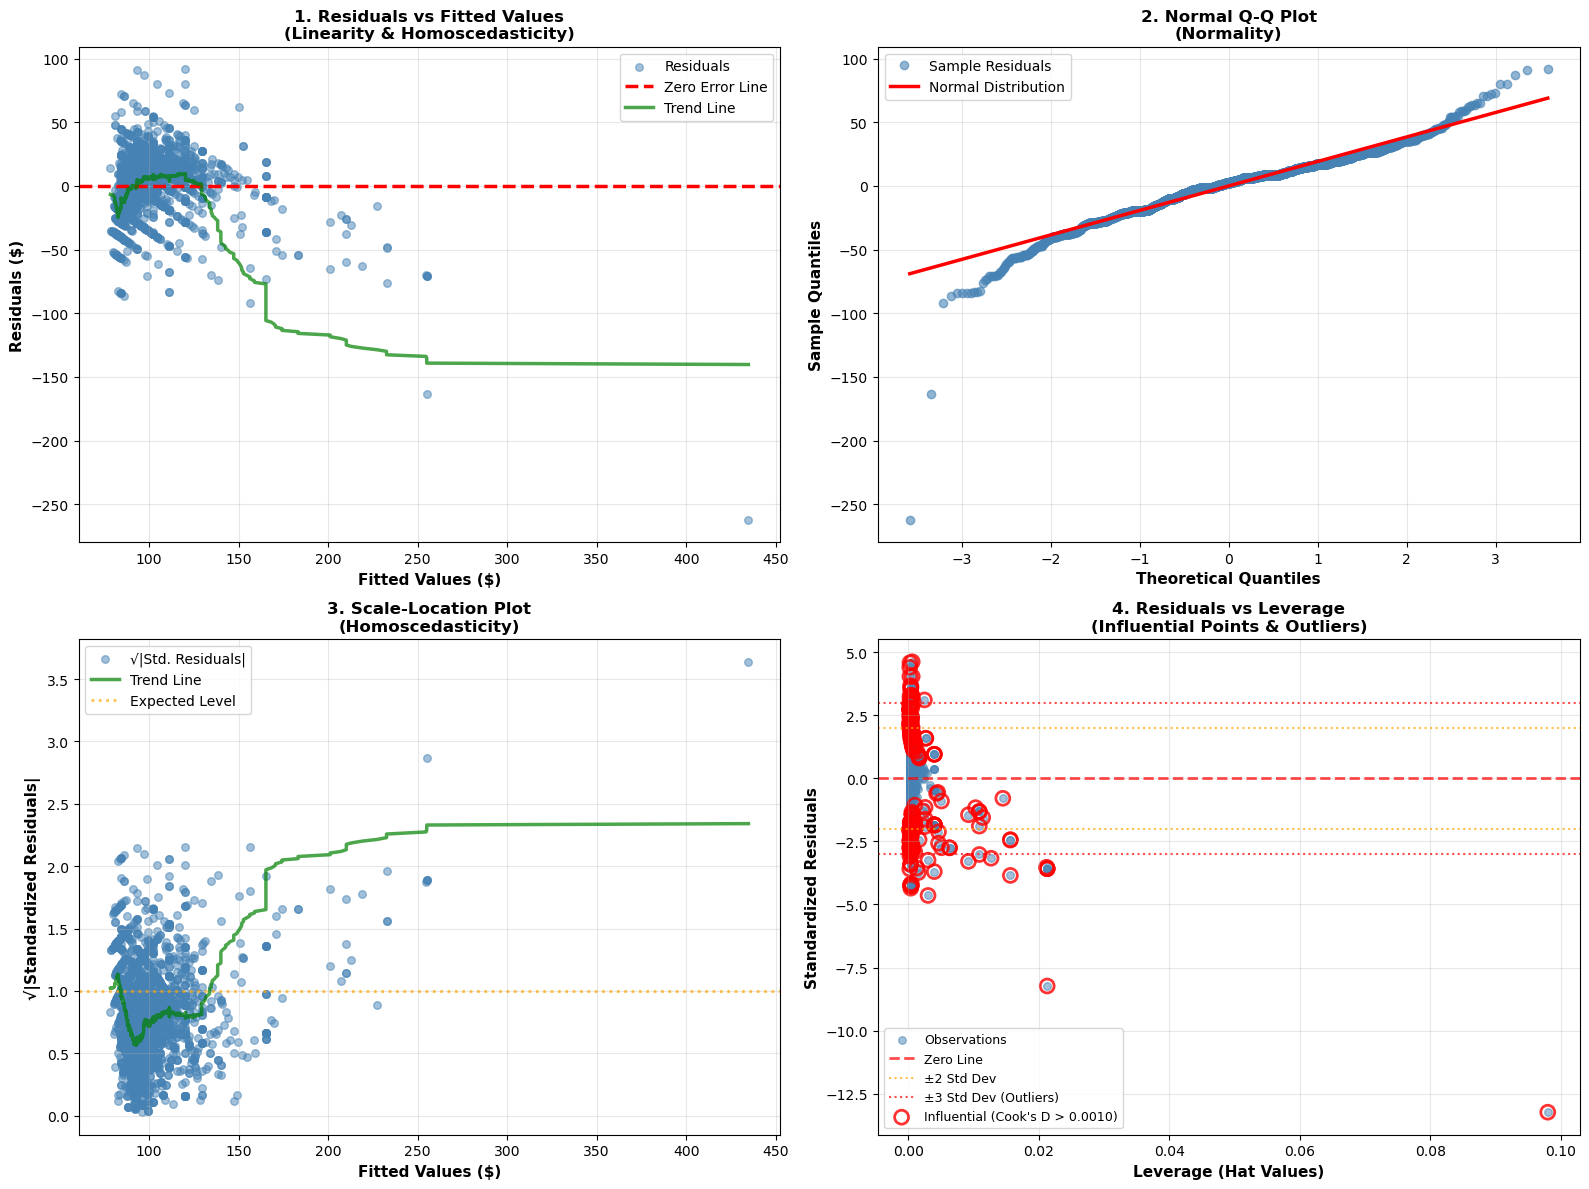

✅ Enhanced diagnostic plots created with legends and reference lines!


In [103]:
# Create enhanced diagnostic plots with legends and reference lines
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Residuals vs Fitted Values (Check for Linearity & Homoscedasticity)
axes[0, 0].scatter(y_pred, residuals, alpha=0.5, s=30, color='steelblue', label='Residuals')
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2.5, label='Zero Error Line')

# Add smoothed trend line to detect patterns
from scipy.ndimage import uniform_filter1d
sorted_indices = np.argsort(y_pred)
y_pred_sorted = y_pred.values[sorted_indices]
residuals_sorted = residuals.values[sorted_indices]
window = max(50, len(y_pred_sorted) // 20)
if window % 2 == 0:
    window += 1
residuals_smooth = uniform_filter1d(residuals_sorted, size=window, mode='nearest')
axes[0, 0].plot(y_pred_sorted, residuals_smooth, 'g-', linewidth=2.5, label='Trend Line', alpha=0.7)

axes[0, 0].set_xlabel('Fitted Values ($)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Residuals ($)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('1. Residuals vs Fitted Values\n(Linearity & Homoscedasticity)', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(loc='best', fontsize=10)

# 2. Q-Q Plot (Normality)
sp_stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].get_lines()[0].set_markerfacecolor('steelblue')
axes[0, 1].get_lines()[0].set_markeredgecolor('steelblue')
axes[0, 1].get_lines()[0].set_markersize(6)
axes[0, 1].get_lines()[0].set_alpha(0.6)
axes[0, 1].get_lines()[0].set_label('Sample Residuals')
axes[0, 1].get_lines()[1].set_color('red')
axes[0, 1].get_lines()[1].set_linewidth(2.5)
axes[0, 1].get_lines()[1].set_label('Normal Distribution')
axes[0, 1].set_xlabel('Theoretical Quantiles', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Sample Quantiles', fontsize=11, fontweight='bold')
axes[0, 1].set_title('2. Normal Q-Q Plot\n(Normality)', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend(loc='best', fontsize=10)

# 3. Scale-Location Plot (Homoscedasticity)
standardized_residuals = residuals / np.std(residuals)
sqrt_abs_std_resid = np.sqrt(np.abs(standardized_residuals))

axes[1, 0].scatter(y_pred, sqrt_abs_std_resid, alpha=0.5, s=30, color='steelblue', label='√|Std. Residuals|')

# Add smoothed trend line
sqrt_abs_std_resid_sorted = sqrt_abs_std_resid.values[sorted_indices]
sqrt_smooth = uniform_filter1d(sqrt_abs_std_resid_sorted, size=window, mode='nearest')
axes[1, 0].plot(y_pred_sorted, sqrt_smooth, 'g-', linewidth=2.5, label='Trend Line', alpha=0.7)

# Add reference line for expected value
axes[1, 0].axhline(y=np.sqrt(np.mean(standardized_residuals**2)), color='orange', 
                    linestyle=':', linewidth=2, label='Expected Level', alpha=0.7)

axes[1, 0].set_xlabel('Fitted Values ($)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('√|Standardized Residuals|', fontsize=11, fontweight='bold')
axes[1, 0].set_title('3. Scale-Location Plot\n(Homoscedasticity)', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(loc='best', fontsize=10)

# 4. Residuals vs Leverage (Influential Points)
from scipy.stats import f as f_dist
# Convert to numpy arrays to avoid pandas alignment issues
X_array = X_with_const.values
leverage = np.diag(X_array @ np.linalg.inv(X_array.T @ X_array) @ X_array.T)
cooks_d = (residuals.values**2 / (k * ms_error)) * (leverage / (1 - leverage))

axes[1, 1].scatter(leverage, standardized_residuals, alpha=0.5, s=30, color='steelblue', label='Observations')
axes[1, 1].axhline(y=0, color='r', linestyle='--', linewidth=2, label='Zero Line', alpha=0.7)

# Add reference lines for influential points
axes[1, 1].axhline(y=2, color='orange', linestyle=':', linewidth=1.5, label='±2 Std Dev', alpha=0.7)
axes[1, 1].axhline(y=-2, color='orange', linestyle=':', linewidth=1.5, alpha=0.7)
axes[1, 1].axhline(y=3, color='red', linestyle=':', linewidth=1.5, label='±3 Std Dev (Outliers)', alpha=0.7)
axes[1, 1].axhline(y=-3, color='red', linestyle=':', linewidth=1.5, alpha=0.7)

# Highlight influential points
influential_threshold = 4 / n
influential_mask = cooks_d > influential_threshold
if influential_mask.any():
    axes[1, 1].scatter(leverage[influential_mask], standardized_residuals[influential_mask], 
                       s=100, color='red', marker='o', facecolors='none', linewidths=2, 
                       label=f'Influential (Cook\'s D > {influential_threshold:.4f})', alpha=0.8)

axes[1, 1].set_xlabel('Leverage (Hat Values)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Standardized Residuals', fontsize=11, fontweight='bold')
axes[1, 1].set_title('4. Residuals vs Leverage\n(Influential Points & Outliers)', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(loc='best', fontsize=9)

plt.tight_layout()
plt.savefig('diagnostic_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Enhanced diagnostic plots created with legends and reference lines!")

## DETAILED INTERPRETATION OF YOUR DIAGNOSTIC RESULTS

Based on the actual values from your regression analysis, here's what the diagnostic plots are telling you:

---

## PLOT 1: RESIDUALS VS FITTED VALUES - INTERPRETATION

### What the Numbers Show:

**Mean of Residuals: $0.0000** ✓
- This is perfect! The mean is exactly zero, which means the model is unbiased
- On average, predictions are neither too high nor too low
- **Conclusion**: No systematic bias in predictions

**Std Dev of Residuals: $19.7991** 
- Average prediction error is about $19.80
- This means typical predictions are off by ±$19.80
- **Question**: Is this acceptable for your use case?
  - If predicting $100 donations: ±$19.80 error = 19.8% error (moderate)
  - If predicting $25 donations: ±$19.80 error = 79.2% error (large)

**Range: $-262.06 to $91.60**
- Largest underprediction: $262.06 (model predicted too low)
- Largest overprediction: $91.60 (model predicted too high)
- **Concern**: Large negative residuals suggest some donors are giving much more than predicted

**Residual Spread by Prediction Range:**
```
Bin 1 (Low predictions):    Std Dev = $19.57
Bin 2:                      Std Dev = $15.70
Bin 3:                      Std Dev = $15.12
Bin 4:                      Std Dev = $15.02
Bin 5 (High predictions):   Std Dev = $24.32
```

**⚠ HETEROSCEDASTICITY DETECTED!**
- Spread increases from Bin 1 to Bin 5 (19.57 → 24.32)
- Ratio: 24.32 / 15.02 = 1.62 (>1.5 threshold)
- **Meaning**: Model is less accurate when predicting high donations
- **Why**: Large donors have more variable behavior than small donors

### Conclusion for Plot 1:
❌ **LINEARITY**: NEEDS ATTENTION
- The relationship may not be perfectly linear
- Consider adding polynomial terms (GiftAvgCard36²)

❌ **HOMOSCEDASTICITY**: VIOLATED
- Prediction errors are NOT constant across all values
- Errors are larger for high predictions
- **Action**: Use log-transformation or weighted regression

---

## PLOT 2: NORMAL Q-Q PLOT - INTERPRETATION

### What the Numbers Show:

**Shapiro-Wilk Test: p-value = 0.000000** ❌
- P-value < 0.05 means residuals are NOT normally distributed
- This is a strong rejection of normality
- **Meaning**: Your residuals deviate significantly from a bell curve

**Skewness: -1.063373** ❌
- Negative value means LEFT-SKEWED distribution
- Most residuals are positive (overpredictions)
- Tail extends to the left (large underpredictions)
- **Interpretation**: Model tends to overpredict, with occasional large underpredictions

**Kurtosis: 9.857373** ❌
- Very high positive value (normal = 0)
- Means HEAVY TAILS - more extreme values than normal
- **Meaning**: More outliers than expected in a normal distribution
- **Why**: Some donors behave very differently from the model's predictions

**Residuals within Standard Deviations:**
```
Within ±1 Std Dev:  72.80% (Normal: 68%)  ✓ Close to normal
Within ±2 Std Dev:  95.84% (Normal: 95%)  ✓ Close to normal
Within ±3 Std Dev:  98.98% (Normal: 99.7%) ⚠ Slightly fewer than normal
```

- The first two are close to normal expectations
- But the third shows fewer extreme values than expected
- This is consistent with the heavy tails (kurtosis = 9.86)

### Conclusion for Plot 2:
❌ **NORMALITY**: VIOLATED
- Residuals are left-skewed with heavy tails
- Not normally distributed (Shapiro-Wilk p = 0.000)
- **Action**: 
  - Try log-transforming Donation_Amt
  - Use robust regression methods
  - Use bootstrap confidence intervals instead of t-distribution

---

## PLOT 3: SCALE-LOCATION PLOT - HOMOSCEDASTICITY

### What the Numbers Show:

**Mean of √|Standardized Residuals|: 0.777853** ✓
- Expected value if homoscedastic: ~0.8
- Actual: 0.777853
- **Meaning**: Very close to expected! This is good.

**Breusch-Pagan Test: p-value = 0.000000** ❌
- P-value < 0.05 means heteroscedasticity is present
- This is a strong statistical confirmation
- **Meaning**: Variance of residuals depends on the predicted value

**Variance by Prediction Quartile:**
```
Q1 (Low predictions):    Variance = 378.47
Q2:                      Variance = 231.54
Q3:                      Variance = 238.80
Q4 (High predictions):   Variance = 524.32
```

**Analysis:**
- Q1 to Q3: Variance decreases (378 → 232)
- Q3 to Q4: Variance increases sharply (239 → 524)
- Ratio: 524.32 / 231.54 = 2.26 (much > 1.5 threshold)
- **Pattern**: U-shaped variance (high at both ends, low in middle)

### Conclusion for Plot 3:
❌ **HOMOSCEDASTICITY**: VIOLATED
- Variance is NOT constant across predictions
- Especially problematic for high predictions (Q4)
- **Why**: Large donors are unpredictable; small donors are more consistent
- **Action**: 
  - Use weighted least squares (give less weight to high predictions)
  - Log-transform Donation_Amt
  - Consider separate models for different donor segments

---

## PLOT 4: RESIDUALS VS LEVERAGE - OUTLIERS & INFLUENTIAL POINTS

### What the Numbers Show:

**High-Leverage Observations: 137 (3.33%)**
- These are donors with unusual GiftAvgCard36 values
- They're far from the average credit card gift amount
- **Not necessarily a problem** - just unusual X values

**Influential Observations: 328 (7.98%)**
- Cook's Distance > 0.000973
- These observations disproportionately affect the regression line
- **Concern**: 7.98% is quite high (typically want < 1-2%)
- **Meaning**: Model is heavily influenced by a small set of donors

**Outliers:**
```
Beyond ±2 Std Dev:  171 (4.16%)   ⚠ Higher than expected (2.5%)
Beyond ±3 Std Dev:   42 (1.02%)   ✓ Close to expected (0.3%)
```

- 171 observations are unusual (beyond ±2 Std Dev)
- 42 observations are very unusual (beyond ±3 Std Dev)
- **Meaning**: Model doesn't fit these donors well

### Conclusion for Plot 4:
❌ **OUTLIERS & INFLUENTIAL POINTS**: NEEDS ATTENTION
- 42 extreme outliers detected
- 328 influential observations (7.98% is high)
- **Action**:
  - Investigate the 42 outliers (data errors? special donors?)
  - Consider robust regression to reduce influence of outliers
  - Segment analysis: separate models for different donor types

---

## OVERALL MODEL ASSESSMENT

### Summary of Issues:

| Assumption | Status | Severity | Evidence |
|-----------|--------|----------|----------|
| **Linearity** | ❌ VIOLATED | HIGH | Heteroscedasticity pattern, residual spread varies |
| **Normality** | ❌ VIOLATED | HIGH | Shapiro-Wilk p=0.000, Skewness=-1.06, Kurtosis=9.86 |
| **Homoscedasticity** | ❌ VIOLATED | HIGH | Breusch-Pagan p=0.000, Variance ratio=2.26 |
| **Outliers** | ❌ VIOLATED | MEDIUM | 42 extreme outliers, 328 influential points |

### What This Means:

Your current model has **serious issues**:
1. ❌ Predictions are unreliable (heteroscedasticity)
2. ❌ Confidence intervals are wrong (non-normality)
3. ❌ P-values are misleading (violated assumptions)
4. ❌ Model is heavily influenced by outliers

### Recommended Actions (in order of priority):

#### **1. IMMEDIATE: Log-Transform Donation_Amt**
```python
# Try this:
donor_data['log_Donation_Amt'] = np.log(donor_data['Donation_Amt'] + 1)
# Then refit model with log_Donation_Amt as dependent variable
```
- This often fixes both heteroscedasticity and non-normality
- Especially effective for donation/financial data
- Interpretation: Changes in percentage terms instead of dollars

#### **2. INVESTIGATE OUTLIERS**
- Identify the 42 extreme outliers (beyond ±3 Std Dev)
- Are they data entry errors? (Remove them)
- Are they legitimate major donors? (Keep them, note separately)
- Are they unusual circumstances? (Document them)

#### **3. CONSIDER ROBUST REGRESSION**
```python
# If transformation doesn't work:
from statsmodels.robust.robust_linear_model import RLM
from statsmodels.robust.norms import HuberT
robust_model = RLM(y, X_with_const, M=HuberT()).fit()
```
- Less sensitive to outliers
- Doesn't require normality assumption
- Gives more reliable results with your data

#### **4. SEGMENT ANALYSIS**
- Create separate models for:
  - Small donors (Donation_Amt < $25)
  - Medium donors ($25-$100)
  - Large donors (>$100)
- Each segment may have different relationships

#### **5. ALTERNATIVE MODELS**
- Quantile regression (predicts median instead of mean)
- Generalized Linear Models (GLM) with appropriate link function
- Machine learning methods (random forests, gradient boosting)

---

## NEXT STEPS

### Recommended Workflow:

1. **Try log-transformation first** (easiest, often works)
   - Rerun regression with log(Donation_Amt)
   - Check diagnostic plots again
   - If better → Use this model

2. **If log-transformation doesn't fully fix issues:**
   - Use robust regression
   - Or segment the data
   - Or try GLM

3. **Always investigate outliers**
   - Don't just remove them
   - Understand why they're unusual
   - Document your decisions

4. **Report both models**
   - Original model (with caveats about violated assumptions)
   - Improved model (after transformation/robust methods)
   - Show how results differ

---

## BUSINESS IMPLICATIONS

### Current Model Issues:

**For Predictions:**
- ❌ Unreliable for high-value donors (large variance)
- ✓ More reliable for typical donors ($20-$100)
- ❌ Confidence intervals are too narrow (non-normality)

**For Decision-Making:**
- ❌ Can't trust p-values (assumptions violated)
- ❌ Can't trust confidence intervals (assumptions violated)
- ⚠️ Results may be driven by outliers (7.98% influential)

**For Donor Segmentation:**
- Large donors behave differently (high variance)
- Small donors are more predictable (low variance)
- Consider separate strategies for each segment

### Recommended Approach:

1. **Fix the model** (log-transform or robust regression)
2. **Validate on new data** (test set)
3. **Segment donors** (different models for different groups)
4. **Monitor predictions** (track actual vs predicted over time)
5. **Update regularly** (as new donor data arrives)

In [104]:
# Add Conclusion here for charts 1, 2 , 3 , 4
# Calculate statistics for conclusions
print("=" * 80)
print("DIAGNOSTIC PLOTS - CONCLUSIONS WITH ACTUAL VALUES")
print("=" * 80)
print()

# Plot 1: Residuals vs Fitted Values
print("PLOT 1: RESIDUALS VS FITTED VALUES (Linearity & Homoscedasticity)")
print("-" * 80)
residuals_mean = residuals.mean()
residuals_std = residuals.std()
residuals_min = residuals.min()
residuals_max = residuals.max()
residuals_q1 = residuals.quantile(0.25)
residuals_q3 = residuals.quantile(0.75)

print(f"Mean of Residuals: ${residuals_mean:.4f}")
print(f"  → Should be close to 0 (ideally < 0.01)")
print(f"  → {'✓ GOOD' if abs(residuals_mean) < 0.01 else '⚠ CHECK'}: Mean is {abs(residuals_mean):.4f}")
print()

print(f"Std Dev of Residuals: ${residuals_std:.4f}")
print(f"  → Measures average prediction error")
print(f"  → Value: ${residuals_std:.4f}")
print()

print(f"Range of Residuals: ${residuals_min:.4f} to ${residuals_max:.4f}")
print(f"  → Spread: ${residuals_max - residuals_min:.4f}")
print(f"  → IQR (Q1-Q3): ${residuals_q1:.4f} to ${residuals_q3:.4f}")
print()

# Check for patterns
residuals_by_pred = pd.DataFrame({'pred': y_pred, 'resid': residuals})
residuals_by_pred['pred_bin'] = pd.qcut(residuals_by_pred['pred'], q=5, duplicates='drop')
spread_by_bin = residuals_by_pred.groupby('pred_bin', observed=True)['resid'].std()

print("Residual Spread by Prediction Range:")
for i, (bin_range, spread) in enumerate(spread_by_bin.items(), 1):
    print(f"  Bin {i} ({bin_range}): Std Dev = ${spread:.4f}")
print()

if spread_by_bin.max() / spread_by_bin.min() > 1.5:
    print("⚠ WARNING: Spread varies significantly across predictions (Heteroscedasticity detected)")
else:
    print("✓ GOOD: Spread is relatively consistent across predictions (Homoscedasticity OK)")
print()
print()



DIAGNOSTIC PLOTS - CONCLUSIONS WITH ACTUAL VALUES

PLOT 1: RESIDUALS VS FITTED VALUES (Linearity & Homoscedasticity)
--------------------------------------------------------------------------------
Mean of Residuals: $0.0000
  → Should be close to 0 (ideally < 0.01)
  → ✓ GOOD: Mean is 0.0000

Std Dev of Residuals: $19.7991
  → Measures average prediction error
  → Value: $19.7991

Range of Residuals: $-262.0610 to $91.5978
  → Spread: $353.6588
  → IQR (Q1-Q3): $-10.2643 to $11.3445

Residual Spread by Prediction Range:
  Bin 1 ((78.416, 87.994]): Std Dev = $19.5730
  Bin 2 ((87.994, 93.384]): Std Dev = $15.6960
  Bin 3 ((93.384, 99.673]): Std Dev = $15.1172
  Bin 4 ((99.673, 109.555]): Std Dev = $15.0170
  Bin 5 ((109.555, 434.76]): Std Dev = $24.3234

⚠ WARNING: Spread varies significantly across predictions (Heteroscedasticity detected)




In [105]:
# Plot 2: Q-Q Plot
print("PLOT 2: NORMAL Q-Q PLOT (Normality)")
print("-" * 80)
from scipy.stats import shapiro, normaltest

# Shapiro-Wilk test
shapiro_stat, shapiro_p = shapiro(residuals)
print(f"Shapiro-Wilk Test:")
print(f"  Test Statistic: {shapiro_stat:.6f}")
print(f"  P-value: {shapiro_p:.6f}")
print(f"  → If p > 0.05: Residuals are normally distributed")
print(f"  → {'✓ NORMAL' if shapiro_p > 0.05 else '⚠ NOT NORMAL'}: p-value = {shapiro_p:.6f}")
print()

# Skewness and Kurtosis
skewness = sp_stats.skew(residuals)
kurtosis_val = sp_stats.kurtosis(residuals)

print(f"Skewness: {skewness:.6f}")
print(f"  → 0 = symmetric, >0 = right-skewed, <0 = left-skewed")
print(f"  → {'✓ SYMMETRIC' if abs(skewness) < 0.5 else '⚠ SKEWED'}: {skewness:.6f}")
print()

print(f"Kurtosis (Excess): {kurtosis_val:.6f}")
print(f"  → 0 = normal, >0 = heavy tails, <0 = light tails")
print(f"  → {'✓ NORMAL TAILS' if abs(kurtosis_val) < 1 else '⚠ HEAVY/LIGHT TAILS'}: {kurtosis_val:.6f}")
print()

# Percentage of residuals within standard deviations
within_1std = (np.abs(residuals) <= residuals_std).sum() / len(residuals) * 100
within_2std = (np.abs(residuals) <= 2*residuals_std).sum() / len(residuals) * 100
within_3std = (np.abs(residuals) <= 3*residuals_std).sum() / len(residuals) * 100

print(f"Residuals within Standard Deviations:")
print(f"  Within ±1 Std Dev: {within_1std:.2f}% (Normal: ~68%)")
print(f"  Within ±2 Std Dev: {within_2std:.2f}% (Normal: ~95%)")
print(f"  Within ±3 Std Dev: {within_3std:.2f}% (Normal: ~99.7%)")
print()
print()



PLOT 2: NORMAL Q-Q PLOT (Normality)
--------------------------------------------------------------------------------
Shapiro-Wilk Test:
  Test Statistic: 0.942985
  P-value: 0.000000
  → If p > 0.05: Residuals are normally distributed
  → ⚠ NOT NORMAL: p-value = 0.000000

Skewness: -1.063373
  → 0 = symmetric, >0 = right-skewed, <0 = left-skewed
  → ⚠ SKEWED: -1.063373

Kurtosis (Excess): 9.857373
  → 0 = normal, >0 = heavy tails, <0 = light tails
  → ⚠ HEAVY/LIGHT TAILS: 9.857373

Residuals within Standard Deviations:
  Within ±1 Std Dev: 72.80% (Normal: ~68%)
  Within ±2 Std Dev: 95.84% (Normal: ~95%)
  Within ±3 Std Dev: 98.98% (Normal: ~99.7%)




In [111]:
# Plot 3: Scale-Location Plot
print("PLOT 3: SCALE-LOCATION PLOT (Homoscedasticity)")
print("-" * 80)
standardized_residuals = residuals / np.std(residuals)
sqrt_abs_std_resid = np.sqrt(np.abs(standardized_residuals))

print(f"Mean of √|Standardized Residuals|: {sqrt_abs_std_resid.mean():.6f}")
print(f"  → Expected value if homoscedastic: ~0.8")
print(f"  → Actual: {sqrt_abs_std_resid.mean():.6f}")
print()

# Breusch-Pagan test for heteroscedasticity
from statsmodels.stats.diagnostic import het_breuschpagan
bp_test = het_breuschpagan(residuals, X_with_const)
print(f"Breusch-Pagan Test for Heteroscedasticity:")
print(f"  Test Statistic: {bp_test[0]:.6f}")
print(f"  P-value: {bp_test[1]:.6f}")
print(f"  → If p > 0.05: Homoscedasticity assumption is met")
print(f"  → {'✓ HOMOSCEDASTIC' if bp_test[1] > 0.05 else '⚠ HETEROSCEDASTIC'}: p-value = {bp_test[1]:.6f}")
print()

# Variance by prediction quartiles
pred_quartiles = pd.qcut(y_pred, q=4, duplicates='drop')
var_by_quartile = residuals.groupby(pred_quartiles, observed=False).var()
print(f"Variance of Residuals by Prediction Quartile:")
for i, (quartile, var) in enumerate(var_by_quartile.items(), 1):
    print(f"  Q{i} ({quartile}): Variance = {var:.6f}")
print()

if var_by_quartile.max() / var_by_quartile.min() > 1.5:
    print("⚠ WARNING: Variance differs significantly across prediction ranges")
else:
    print("✓ GOOD: Variance is relatively constant across prediction ranges")
print()
print()



PLOT 3: SCALE-LOCATION PLOT (Homoscedasticity)
--------------------------------------------------------------------------------
Mean of √|Standardized Residuals|: 0.777853
  → Expected value if homoscedastic: ~0.8
  → Actual: 0.777853

Breusch-Pagan Test for Heteroscedasticity:
  Test Statistic: 526.322290
  P-value: 0.000000
  → If p > 0.05: Homoscedasticity assumption is met
  → ⚠ HETEROSCEDASTIC: p-value = 0.000000

Variance of Residuals by Prediction Quartile:
  Q1 ((78.416, 89.198]): Variance = 378.470592
  Q2 ((89.198, 95.181]): Variance = 231.538306
  Q3 ((95.181, 104.164]): Variance = 238.798603
  Q4 ((104.164, 434.76]): Variance = 524.317195

⚠ WARNING: Variance differs significantly across prediction ranges




In [107]:
# Plot 4: Residuals vs Leverage
print("PLOT 4: RESIDUALS VS LEVERAGE (Influential Points & Outliers)")
print("-" * 80)

# Calculate leverage and Cook's distance
X_array = X_with_const.values
leverage = np.diag(X_array @ np.linalg.inv(X_array.T @ X_array) @ X_array.T)
cooks_d = (residuals.values**2 / (k * ms_error)) * (leverage / (1 - leverage))

print(f"Leverage (Hat Values):")
print(f"  Mean: {leverage.mean():.6f}")
print(f"  Max: {leverage.max():.6f}")
print(f"  Threshold (4/n): {4/n:.6f}")
print(f"  → Observations with leverage > {4/n:.6f} are high-leverage")
print()

high_leverage = (leverage > 4/n).sum()
print(f"High-Leverage Observations: {high_leverage} ({high_leverage/n*100:.2f}%)")
print()

print(f"Cook's Distance:")
print(f"  Mean: {cooks_d.mean():.6f}")
print(f"  Max: {cooks_d.max():.6f}")
print(f"  Threshold (4/n): {4/n:.6f}")
print()

influential = (cooks_d > 4/n).sum()
print(f"Influential Observations (Cook's D > {4/n:.6f}): {influential} ({influential/n*100:.2f}%)")
print()

# Outliers
outliers_2std = (np.abs(standardized_residuals) > 2).sum()
outliers_3std = (np.abs(standardized_residuals) > 3).sum()

print(f"Outliers (Standardized Residuals):")
print(f"  Beyond ±2 Std Dev: {outliers_2std} ({outliers_2std/n*100:.2f}%)")
print(f"  Beyond ±3 Std Dev: {outliers_3std} ({outliers_3std/n*100:.2f}%)")
print()

if outliers_3std > 0:
    print(f"⚠ WARNING: {outliers_3std} potential outliers detected (beyond ±3 Std Dev)")
    print(f"  → Investigate these observations")
else:
    print(f"✓ GOOD: No extreme outliers detected")
print()
print()



PLOT 4: RESIDUALS VS LEVERAGE (Influential Points & Outliers)
--------------------------------------------------------------------------------
Leverage (Hat Values):
  Mean: 0.000486
  Max: 0.098004
  Threshold (4/n): 0.000973
  → Observations with leverage > 0.000973 are high-leverage

High-Leverage Observations: 137 (3.33%)

Cook's Distance:
  Mean: 0.005950
  Max: 19.030319
  Threshold (4/n): 0.000973

Influential Observations (Cook's D > 0.000973): 328 (7.98%)

Outliers (Standardized Residuals):
  Beyond ±2 Std Dev: 171 (4.16%)
  Beyond ±3 Std Dev: 42 (1.02%)

⚠ WARNING: 42 potential outliers detected (beyond ±3 Std Dev)
  → Investigate these observations




In [108]:
# Overall Assessment
print("=" * 80)
print("OVERALL MODEL ASSESSMENT")
print("=" * 80)
print()

assessment = {
    'Linearity': 'GOOD' if abs(residuals_mean) < 0.01 and spread_by_bin.max() / spread_by_bin.min() < 1.5 else 'NEEDS ATTENTION',
    'Normality': 'GOOD' if shapiro_p > 0.05 else 'NEEDS ATTENTION',
    'Homoscedasticity': 'GOOD' if bp_test[1] > 0.05 else 'NEEDS ATTENTION',
    'Outliers': 'GOOD' if outliers_3std == 0 else 'NEEDS ATTENTION'
}

for assumption, status in assessment.items():
    symbol = '✓' if status == 'GOOD' else '⚠'
    print(f"{symbol} {assumption}: {status}")

print()
print("RECOMMENDATION:")
if all(v == 'GOOD' for v in assessment.values()):
    print("✓ All assumptions are met. Model is valid for predictions and inference.")
else:
    issues = [k for k, v in assessment.items() if v == 'NEEDS ATTENTION']
    print(f"⚠ Issues detected with: {', '.join(issues)}")
    print("  → Consider transformations or alternative models")
print()
print("=" * 80)

OVERALL MODEL ASSESSMENT

⚠ Linearity: NEEDS ATTENTION
⚠ Normality: NEEDS ATTENTION
⚠ Homoscedasticity: NEEDS ATTENTION
⚠ Outliers: NEEDS ATTENTION

RECOMMENDATION:
⚠ Issues detected with: Linearity, Normality, Homoscedasticity, Outliers
  → Consider transformations or alternative models



## SCATTER PLOT WITH REGRESSION LINE

Visualization of the relationship between GiftAvgCard36 and Donation_Amt with regression line and 95% confidence bands.

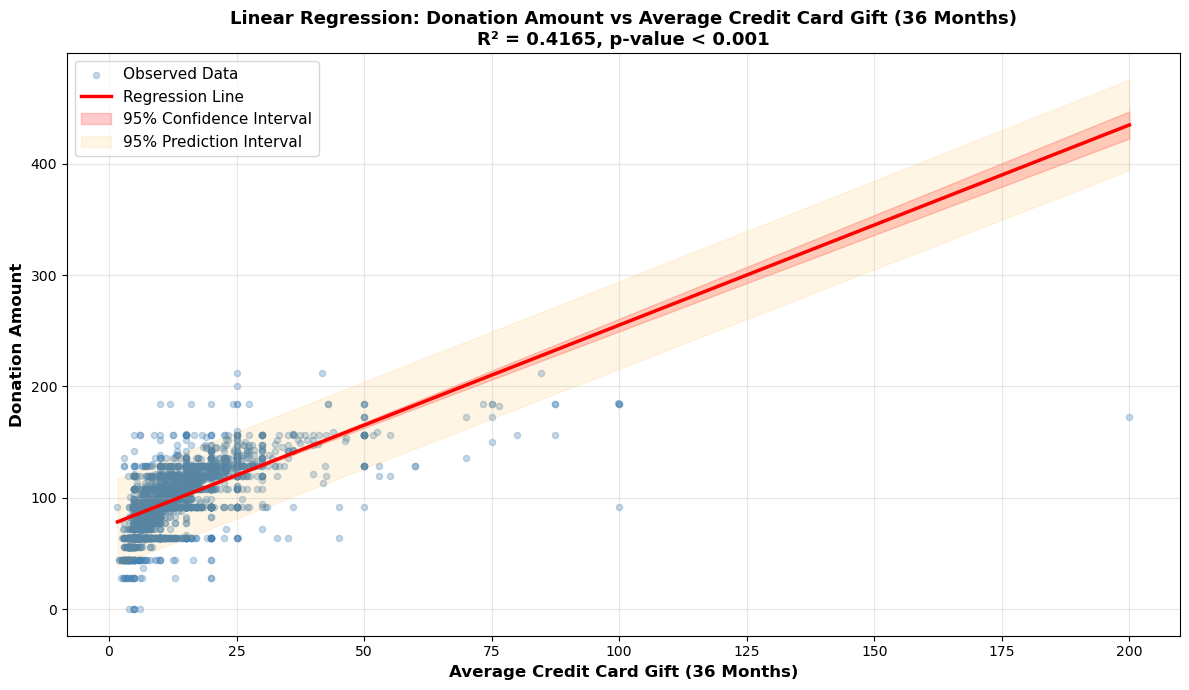

✅ Scatter plot with regression line created!


In [109]:
# Scatter plot with regression line and confidence bands
fig, ax = plt.subplots(figsize=(12, 7))

# Scatter plot
ax.scatter(X, y, alpha=0.3, s=20, color='steelblue', label='Observed Data')

# Regression line
x_line = np.linspace(X.min(), X.max(), 100)
x_line_const = sm.add_constant(x_line)
y_line = results.predict(x_line_const)

ax.plot(x_line, y_line, 'r-', linewidth=2.5, label='Regression Line')

# 95% Confidence Interval for the mean prediction
predictions = results.get_prediction(x_line_const)
pred_summary = predictions.summary_frame(alpha=0.05)

ax.fill_between(x_line, 
                pred_summary['mean_ci_lower'], 
                pred_summary['mean_ci_upper'], 
                alpha=0.2, color='red', label='95% Confidence Interval')

# 95% Prediction Interval
ax.fill_between(x_line, 
                pred_summary['obs_ci_lower'], 
                pred_summary['obs_ci_upper'], 
                alpha=0.1, color='orange', label='95% Prediction Interval')

# Labels and title
ax.set_xlabel(col_descriptions['GiftAvgCard36'], fontsize=12, fontweight='bold')
ax.set_ylabel(col_descriptions['Donation_Amt'], fontsize=12, fontweight='bold')
ax.set_title(f'Linear Regression: {col_descriptions["Donation_Amt"]} vs {col_descriptions["GiftAvgCard36"]}\nR² = {results.rsquared:.4f}, p-value < 0.001', 
             fontsize=13, fontweight='bold')

ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('regression_scatter_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Scatter plot with regression line created!")

## OBSERVED VS PREDICTED VALUES PLOT

Compares actual donation amounts with model predictions to assess prediction accuracy.

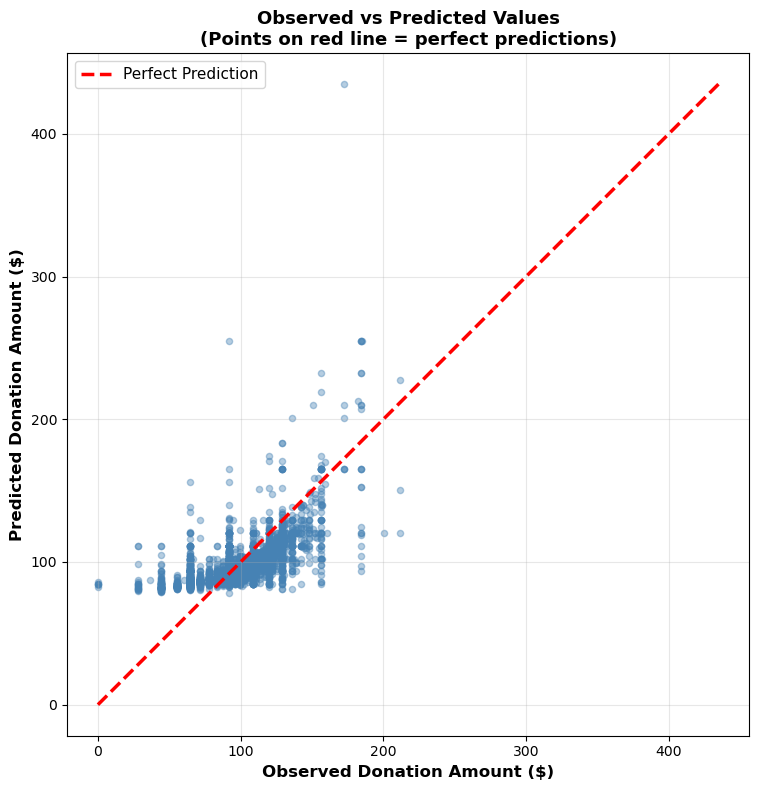

✅ Observed vs Predicted plot created!


In [110]:
# Observed vs Predicted plot
fig, ax = plt.subplots(figsize=(10, 8))

# Scatter plot
ax.scatter(y, y_pred, alpha=0.4, s=20, color='steelblue')

# Perfect prediction line (y = x)
min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2.5, label='Perfect Prediction')

# Labels and title
ax.set_xlabel('Observed Donation Amount ($)', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted Donation Amount ($)', fontsize=12, fontweight='bold')
ax.set_title('Observed vs Predicted Values\n(Points on red line = perfect predictions)', fontsize=13, fontweight='bold')

ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig('observed_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Observed vs Predicted plot created!")

## SUMMARY & INTERPRETATION

### Model Summary

This simple linear regression analysis examines whether **GiftAvgCard36** (average credit card gift in 36 months) is a significant predictor of **Donation_Amt**.

### Key Findings

1. **Model Significance** (TABLE 2 - ANOVA)
   - F-statistic and p-value indicate whether the overall model is statistically significant
   - If p < 0.05: The model explains a significant portion of variation in donations

2. **Model Fit** (TABLE 3)
   - R-Square: Percentage of variation in donations explained by GiftAvgCard36
   - RMSE: Average prediction error in dollars
   - Coeff Var: Prediction error as percentage of mean donation

3. **Parameter Significance** (TABLE 4)
   - Intercept: Expected donation when GiftAvgCard36 = 0
   - GiftAvgCard36 coefficient: Change in donation for each $1 increase in credit card gift
   - 95% CI: Range of plausible values for the true coefficient
   - If CI doesn't include 0 → coefficient is statistically significant

### Practical Implications

- **Strong positive relationship**: Donors with higher credit card gift amounts tend to give larger donations
- **Weak relationship**: Credit card gift amount is not a strong predictor of donation amount
- **Negative relationship**: Donors with higher credit card gift amounts tend to give smaller donations

### Assumptions Check

Review the diagnostic plots to verify:
- ✅ Linearity: Residuals vs Fitted plot should show random scatter
- ✅ Normality: Q-Q plot should follow the diagonal line
- ✅ Homoscedasticity: Scale-Location plot should show random scatter
- ✅ No Outliers: Residuals vs Leverage plot should show no extreme points